In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import re
import numpy as np
import pickle
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
from geopy.exc import GeocoderUnavailable
from time import sleep
import matplotlib.pyplot as plot


##### reading in data 

In [2]:
yr2023 = pd.read_csv('fortwayne2023.csv')
yr2023.head(6)                     

,Incident number,Incident nature,Area location code,Incident address,When reported,Occurred after,Occurred before,City,Offense code,Offense code.1,Offense code.2,Disposition
0,23F000001,113 SHOTS FIRED,F11A5,1945 GRISWOLD DR,1/1/2023 0:01,1/1/2023 0:00,1/1/2023 0:00,FORT WAYNE,113,,,UNF
1,23F000003,113 SHOTS FIRED,F41B5,WINTER ST & E LEWIS ST,1/1/2023 0:02,1/1/2023 0:02,1/1/2023 0:02,FORT WAYNE,113,,,INA
2,23F000004,"43,62",F1643,2737 W WASHINGTON CENTER RD,1/1/2023 0:06,1/1/2023 0:05,1/1/2023 0:05,FORT WAYNE,DFCL,CDIS,,R
3,23F000005,113 SHOTS FIRED,F42A5,305 E DEWALD ST,1/1/2023 0:01,1/1/2023 0:00,1/1/2023 0:00,FORT WAYNE,113,,,INA
4,23F000006,48 SUSPICIOUS,F32D5,3410 S CALHOUN ST,1/1/2023 0:10,1/1/2023 0:08,1/1/2023 0:08,FORT WAYNE,48,,,INA
5,23F000007,70 FIRE,F23N1,7201 MIAHQUEAH Ct,1/1/2023 0:20,1/1/2023 0:18,1/1/2023 0:18,FORT WAYNE,70,,,INA


In [3]:
yr2023["Incident nature"].str.extract(r'(\d*)')

,0
0,113
1,113
2,43
3,113
4,48
...,...
154473,111
154474,111
154475,111
154476,48


##### determining violent/non violent crimes

In [4]:
# Categorize violent and non violent
# Reading textfile and creating a mapping dictionary
violent_incident_types = []
nonviolent_incident_types = []
with open('incident_list.txt', 'r') as file:
    for line in file:
        if'-' in line:
            incident_type, classification = line.strip().rsplit(' - ', 1)
            if classification.strip().lower() == 'violent': 
                violent_incident_types.append(incident_type.strip())
            if classification.strip().lower() == 'nonviolent': 
                nonviolent_incident_types.append(incident_type.strip())


print("Violent Incident Types:", violent_incident_types)
print("Non-Violent Incident Types:", nonviolent_incident_types)



Violent Incident Types: ['SHOTS FIRED', 'FIRE', 'VAND VEH', 'JO', 'RECKLESS DRI', 'PI ACCIDENT', 'CUTTING', 'PD ACCIDENT', 'I JUV INVEST', 'T SUICIDE THR', 'DUI', 'A DEATH NOTIF', 'RAPE', 'FIGHT', 'THEFT', 'ARMED ROB', 'BATTERY', 'TX THREATS', 'STOLEN VEHIC', 'A SUICIDE ATT', 'BURGLARY', 'PURSUIT', 'R STOLEN RECO', 'STRONG ARM', 'MAN DOWN', 'BOMB THREAT', 'V MENTAL VIOL', 'SHOOTING', 'HARASSMENT', 'THREATS', 'PARTY ARMED', 'I INTRUSION', 'N CHILD NEGLE', 'MOLESTING', 'HS PI HITSKIP', 'I INJURED', 'ATTEMPTED', 'P DEER PERMI', 'PP PINNED', 'F FATAL ACC', 'KIDNAPPING', 'PROWLER', 'FIRE', 'HOUSE FIRE', 'SUICIDE ATTEMPT']
Non-Violent Incident Types: ['SUSPICIOUS', 'DISTURBANCE', 'MEET', 'HS HIT SKIP', 'UNWANTED', 'EMS', 'DISABLED VEH', 'PARKING VIOL', 'NUISANCE', 'PROBLEM UNK', 'DOMESTIC', 'CONTACT', 'TRAFFIC STOP', 'HANG UP', 'A AUDIBLE', 'MISSING PERS', 'J LOCKED OUT', 'U UNAUTHORIZE', 'MENTALLY ILL', 'TRAFF HAZARD', 'ASSIST', 'VANDALISM', 'REMOVE ITEMS', 'RN RUNAWAY', 'OPEN DOOR', 'MOTOR

In [5]:
# Create a mapping dictionary from the text file
mapping = {}
with open('incident_list.txt', 'r') as file:
    for line in file:
        if '-' in line:
            incident_type, classification = line.strip().rsplit(' - ', 1)
            mapping[incident_type.strip()] = classification.strip().lower()


def extract_incident_type(text):
# finds the first space to find the string
    first_space_index = text.find(' ')
    
    if first_space_index != -1:
        incident_type = text[first_space_index + 1:].strip()
        return incident_type
    
    return None


yr2023['Incident type'] = yr2023['Incident nature'].apply(extract_incident_type)
yr2023['Violent/NonViolent'] = yr2023['Incident type'].map(mapping)
yr2023.head(5)


,Incident number,Incident nature,Area location code,Incident address,When reported,Occurred after,Occurred before,City,Offense code,Offense code.1,Offense code.2,Disposition,Incident type,Violent/NonViolent
0,23F000001,113 SHOTS FIRED,F11A5,1945 GRISWOLD DR,1/1/2023 0:01,1/1/2023 0:00,1/1/2023 0:00,FORT WAYNE,113,,,UNF,SHOTS FIRED,violent
1,23F000003,113 SHOTS FIRED,F41B5,WINTER ST & E LEWIS ST,1/1/2023 0:02,1/1/2023 0:02,1/1/2023 0:02,FORT WAYNE,113,,,INA,SHOTS FIRED,violent
2,23F000004,"43,62",F1643,2737 W WASHINGTON CENTER RD,1/1/2023 0:06,1/1/2023 0:05,1/1/2023 0:05,FORT WAYNE,DFCL,CDIS,,R,,NaN
3,23F000005,113 SHOTS FIRED,F42A5,305 E DEWALD ST,1/1/2023 0:01,1/1/2023 0:00,1/1/2023 0:00,FORT WAYNE,113,,,INA,SHOTS FIRED,violent
4,23F000006,48 SUSPICIOUS,F32D5,3410 S CALHOUN ST,1/1/2023 0:10,1/1/2023 0:08,1/1/2023 0:08,FORT WAYNE,48,,,INA,SUSPICIOUS,nonviolent


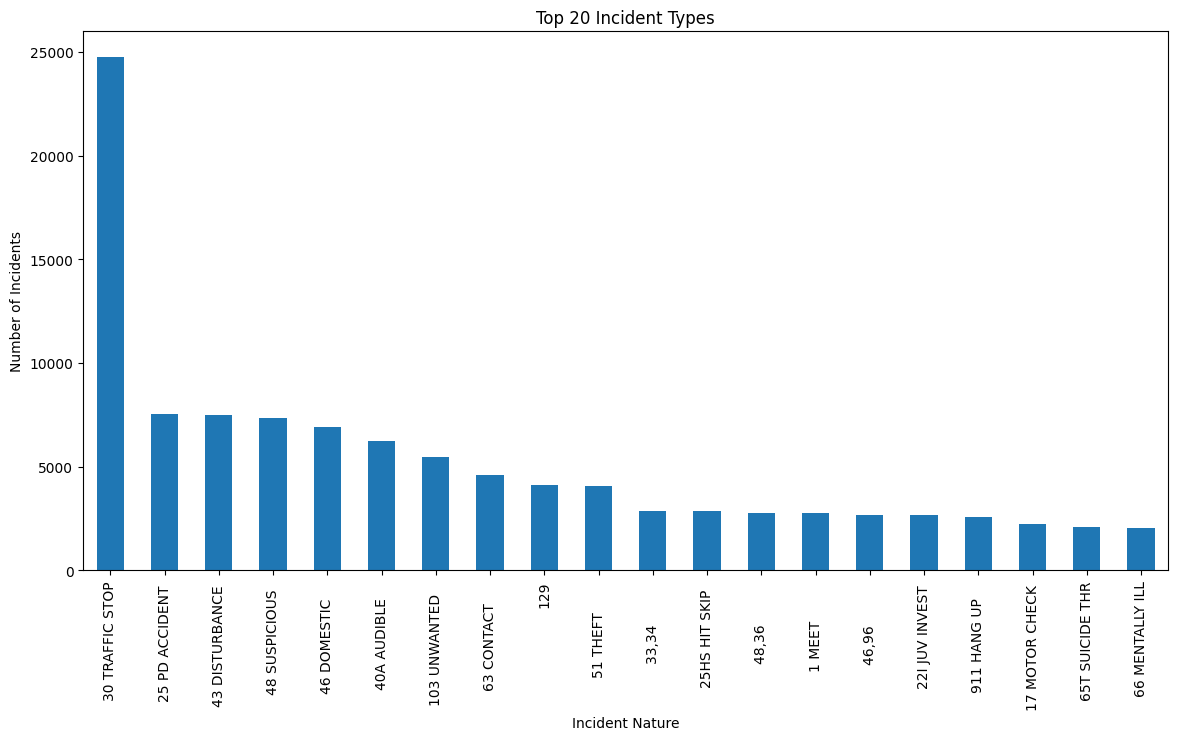

In [7]:
# Plot the most common incident types
incident_counts = yr2023['Incident nature'].value_counts()

plot.figure(figsize=(14, 7))
incident_counts.head(20).plot(kind='bar')
plot.title('Top 20 Incident Types')
plot.xlabel('Incident Nature')
plot.ylabel('Number of Incidents')
plot.show()

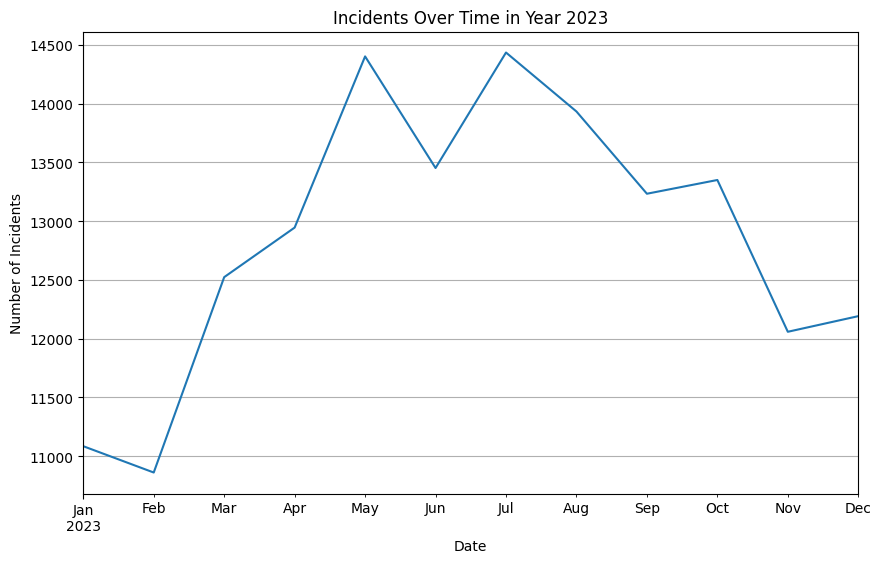

In [8]:
# Incidents each month
yr2023['When reported'] = pd.to_datetime(yr2023['When reported'])
incident_count_byDate = yr2023.groupby(yr2023['When reported'].dt.to_period('M')).size()

plot.figure(figsize=(10,6))
incident_count_byDate.plot()
plot.title('Incidents Over Time in Year 2023')
plot.xlabel('Date')
plot.ylabel('Number of Incidents')
plot.grid(True)
plot.show()